# Exploratory Data Analysis - Pneumonia Chest X-Ray Features

## Background

Notebook `01_feature_engineering.ipynb` (Phase 1) turned every chest X-ray in
`lab/data/{train,val,test}/` into a row of 12 hand-engineered numeric features (pixel
statistics, GLCM texture, Canny edge/contour counts, and left-right region symmetry), saved to
`lab/data/features/{train,val,test}.csv`. Before any of those features are handed to a
classifier in Phase 3 (`03_ml_modeling.ipynb`), this notebook (Phase 2) explores the resulting
tables on their own terms: how imbalanced is the target across splits, do the individual
features look different between the `NORMAL` and `PNEUMONIA` classes, and are any of the 12
features redundant with each other.

The dataset is known (verified during this project's planning) to be imbalanced: the `train`
split has 1341 `NORMAL` images against 3875 `PNEUMONIA` images (~2.89:1), `test` mirrors that
skew (234 `NORMAL` / 390 `PNEUMONIA`), and `val` is a tiny, deliberately balanced 8/8 fixture
used only for early stopping in Phase 4, not for statistics. Confirming this imbalance here
(rather than assuming it) is what justifies Phase 3's choice of native class-weighting
(`class_weight="balanced"` / `scale_pos_weight`) over synthetic oversampling: the class ratio
needs to be seen directly, not just quoted from a spec.

This notebook is purely descriptive: it loads the three CSVs, plots and tabulates them, and
draws no conclusions that depend on model fitting. Nothing here trains anything.

### Load the engineered feature tables

Everything below depends on `../data/features/{train,val,test}.csv` existing on disk (written
by `01_feature_engineering.ipynb`). Loading all three splits up front, and pinning the list of
the 12 numeric feature columns as a constant, avoids repeating the column list in every section
below.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

FEATURE_COLUMNS = [
    "Mean_Intensity",
    "Std_Intensity",
    "Min_Intensity",
    "Max_Intensity",
    "Contrast",
    "Homogeneity",
    "Energy",
    "Entropy",
    "Edge_Density",
    "Contour_Count",
    "Brightness_Dist",
    "Symmetry",
]

train_df = pd.read_csv("../data/features/train.csv")
val_df = pd.read_csv("../data/features/val.csv")
test_df = pd.read_csv("../data/features/test.csv")

print("train:", train_df.shape)
print("val:  ", val_df.shape)
print("test: ", test_df.shape)

train_df.head()

train: (5216, 15)
val:   (16, 15)
test:  (624, 15)


,Image_ID,File_Path,Mean_Intensity,Std_Intensity,Min_Intensity,Max_Intensity,Contrast,Homogeneity,Energy,Entropy,Edge_Density,Contour_Count,Brightness_Dist,Symmetry,Label
0,IM-0115-0001.jpeg,../data/train/NORMAL/IM-0115-0001.jpeg,128.907466,62.078780,0.0,249.0,0.172385,0.922968,0.346622,3.475010,0.068638,57,-0.464313,0.879371,NORMAL
1,IM-0117-0001.jpeg,../data/train/NORMAL/IM-0117-0001.jpeg,100.650112,59.582701,0.0,250.0,0.206318,0.911229,0.326448,3.612831,0.084303,74,-0.046654,0.902570,NORMAL
2,IM-0119-0001.jpeg,../data/train/NORMAL/IM-0119-0001.jpeg,121.979313,68.655883,0.0,255.0,0.169803,0.925817,0.339768,3.508608,0.056840,53,-0.478458,0.925946,NORMAL
3,IM-0122-0001.jpeg,../data/train/NORMAL/IM-0122-0001.jpeg,132.990753,64.805750,0.0,255.0,0.149624,0.932178,0.361069,3.370159,0.047772,40,-0.686743,0.911159,NORMAL
4,IM-0125-0001.jpeg,../data/train/NORMAL/IM-0125-0001.jpeg,106.225865,64.842846,0.0,254.0,0.236867,0.902712,0.323028,3.677723,0.086934,90,-0.231987,0.890668,NORMAL


### Target variable analysis: class balance per split

Every downstream modeling decision in Phase 3 hinges on how imbalanced `Label` actually is in
each split of the *feature* tables (not just the raw image counts quoted in the Background).
Value counts confirm the imbalance is preserved after feature extraction (it should be, since
feature extraction does not drop or duplicate rows), and a `countplot` per split makes the
skew visible at a glance rather than as a bare ratio.

In [20]:
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    counts = df["Label"].value_counts()
    proportions = df["Label"].value_counts(normalize=True).round(3)
    summary = pd.concat([counts.rename("count"), proportions.rename("proportion")], axis=1)
    print(f"--- {name} (n={len(df)}) ---")
    print(summary)
    print()

--- train (n=5216) ---
           count  proportion
Label                       
PNEUMONIA   3875       0.743
NORMAL      1341       0.257

--- val (n=16) ---
           count  proportion
Label                       
NORMAL         8         0.5
PNEUMONIA      8         0.5

--- test (n=624) ---
           count  proportion
Label                       
PNEUMONIA    390       0.625
NORMAL       234       0.375



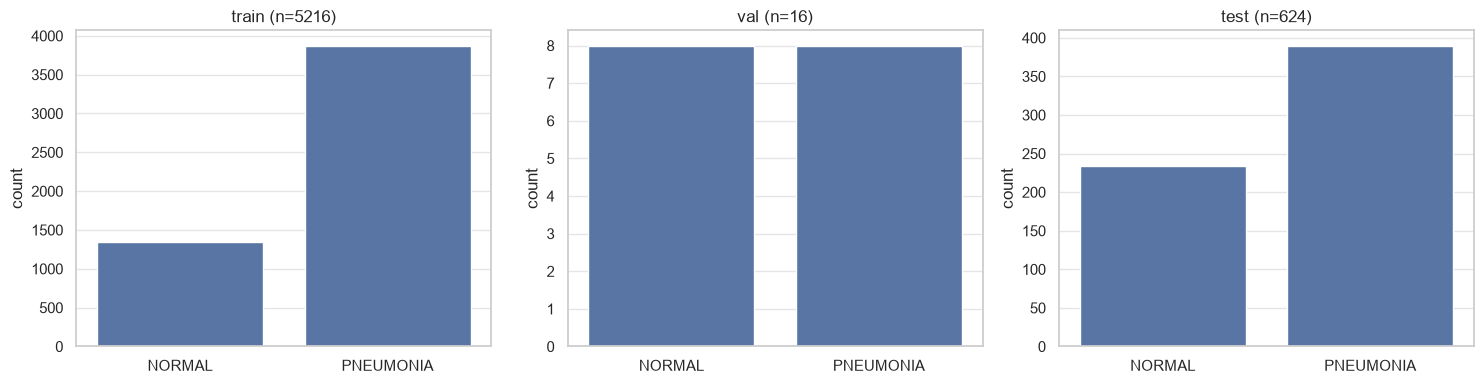

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, [("train", train_df), ("val", val_df), ("test", test_df)]):
    sns.countplot(x="Label", data=df, order=["NORMAL", "PNEUMONIA"], ax=ax)
    ax.set_title(f"{name} (n={len(df)})")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

### Numerical feature analysis: distribution by class

Each of the 12 engineered features is a candidate predictor for Phase 3. Comparing their
summary statistics between `NORMAL` and `PNEUMONIA` on the `train` split, and looking at the
same comparison as boxplots, is how visible separability is judged before any model is fit -- a
feature whose `NORMAL`/`PNEUMONIA` boxes barely overlap is a strong candidate; one whose boxes
sit on top of each other is not, regardless of what a classifier later does with it.

In [22]:
train_df.groupby("Label")[FEATURE_COLUMNS].describe().T

Label                      NORMAL    PNEUMONIA
Mean_Intensity count  1341.000000  3875.000000
               mean    122.383597   123.200773
               std      12.955339    20.108089
               min      73.291912    60.688576
               25%     114.065250   110.666763
...                           ...          ...
Symmetry       min       0.771705     0.730924
               25%       0.864734     0.872122
               50%       0.887399     0.894089
               75%       0.904905     0.911773
               max       0.948590     0.958454

[96 rows x 2 columns]

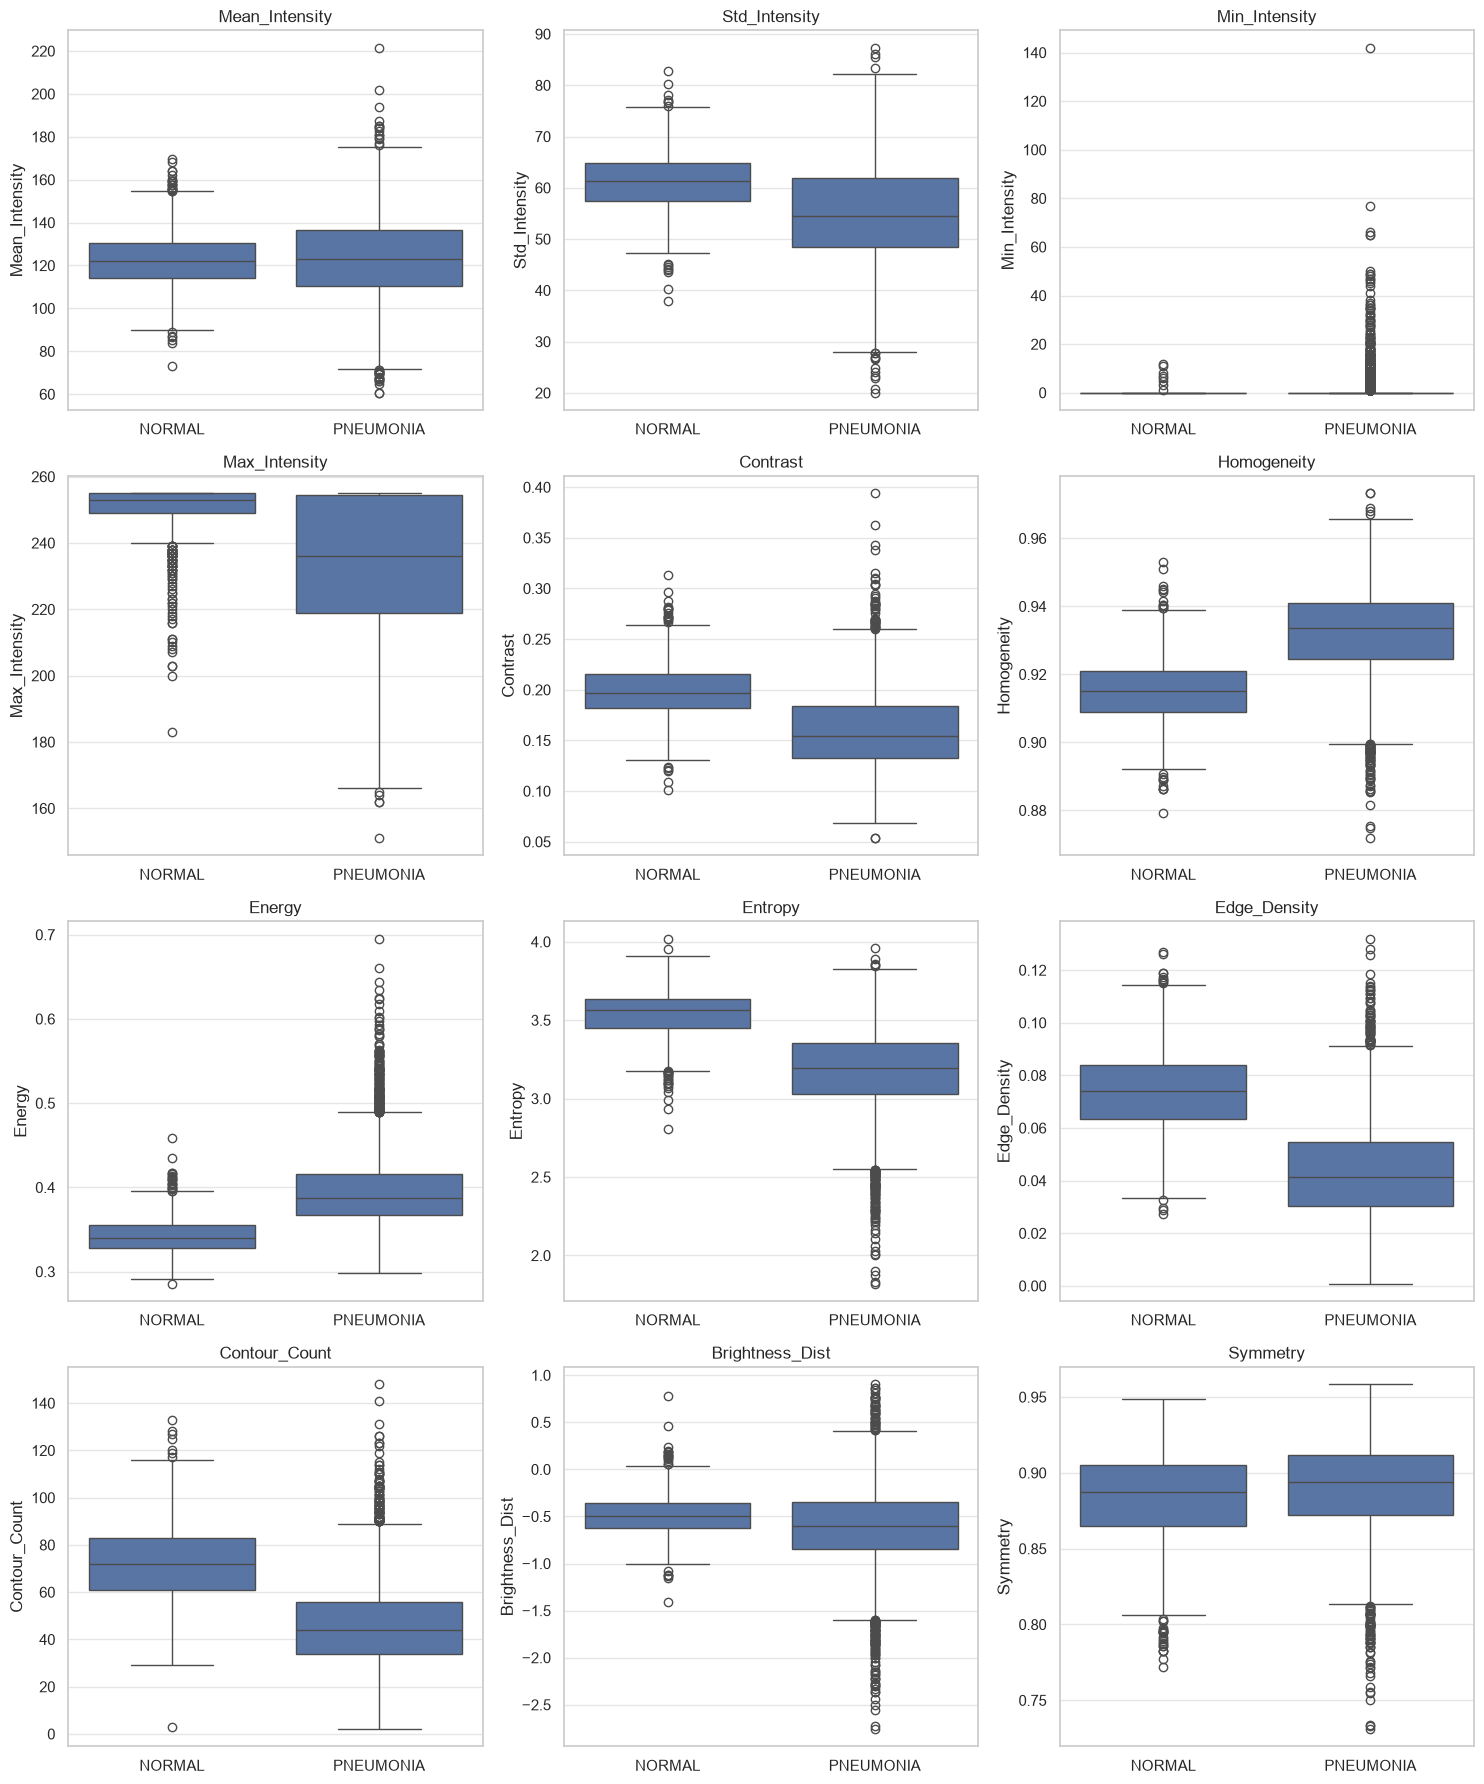

In [23]:
fig, axes = plt.subplots(4, 3, figsize=(15, 18))
for ax, col in zip(axes.flatten(), FEATURE_COLUMNS):
    sns.boxplot(x="Label", y=col, data=train_df, order=["NORMAL", "PNEUMONIA"], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

### Categorical / derived analysis: pneumonia rate by intensity band

`Mean_Intensity` is continuous, which makes it hard to read as a single number. Binning it into
tertiles (`low`/`medium`/`high`) via `pd.qcut` and cross-tabulating against `Label` turns it
into a "Pneumonia Rate (%)" table -- the kind of simple, directly-readable summary a
non-technical reader can interpret without knowing what a boxplot is, and a quick check for
whether overall brightness relates to diagnosis monotonically or not at all.

In [24]:
train_df["Mean_Intensity_Band"] = pd.qcut(
    train_df["Mean_Intensity"], q=3, labels=["low", "medium", "high"]
)

intensity_crosstab = pd.crosstab(train_df["Mean_Intensity_Band"], train_df["Label"])
intensity_crosstab

Label,NORMAL,PNEUMONIA
Mean_Intensity_Band,,
low,396,1343
medium,604,1134
high,341,1398


In [25]:
pneumonia_rate = (
    intensity_crosstab["PNEUMONIA"]
    / (intensity_crosstab["NORMAL"] + intensity_crosstab["PNEUMONIA"])
    * 100
).round(1)

pneumonia_rate_table = pneumonia_rate.rename("Pneumonia Rate (%)").to_frame()
pneumonia_rate_table

,Pneumonia Rate (%)
Mean_Intensity_Band,
low,77.2
medium,65.2
high,80.4


### Multivariable analysis: correlation between engineered features

Several of the 12 features are derived from the same underlying pixel array -- most obviously
`Contrast`, `Homogeneity`, `Energy`, and `Entropy`, which all come from the same GLCM computed
in `extract_texture_features`. A correlation heatmap over the `train` split's 12 numeric
feature columns surfaces exactly which pairs move together, so Phase 3 can decide whether near-
duplicate features need pruning or regularizing rather than being treated as 12 independent
signals.

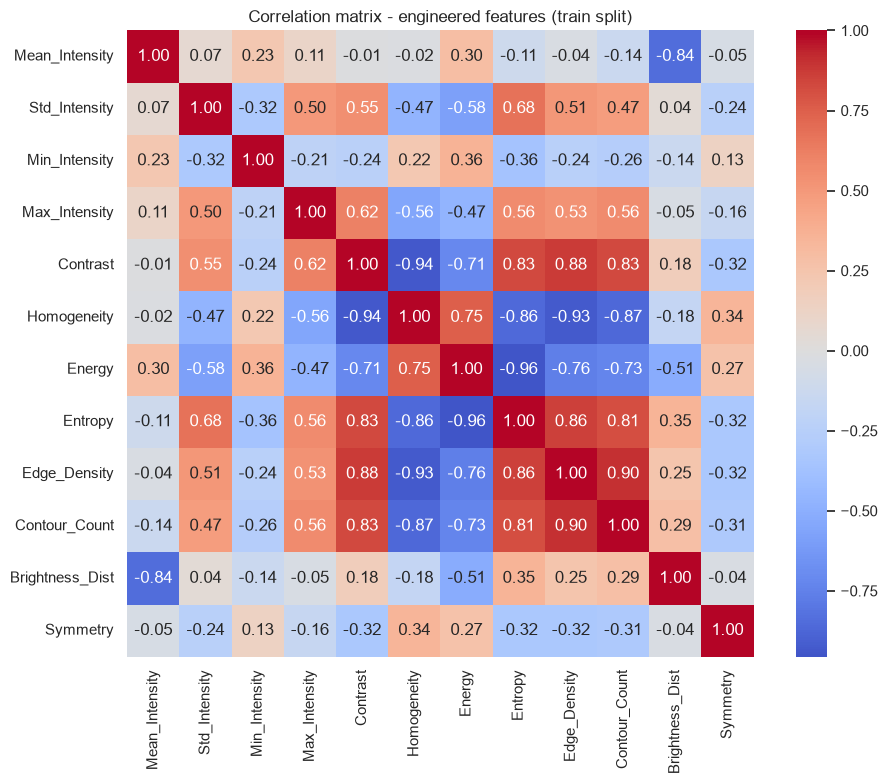

In [26]:
corr = train_df[FEATURE_COLUMNS].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix - engineered features (train split)")
plt.tight_layout()
plt.show()

In [27]:
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    .stack()
    .rename("Correlation")
    .reset_index()
)
corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]
corr_pairs.reindex(
    corr_pairs["Correlation"].abs().sort_values(ascending=False).index
).head(10)

,Feature_1,Feature_2,Correlation
79,Energy,Entropy,-0.955995
53,Contrast,Homogeneity,-0.936541
68,Homogeneity,Edge_Density,-0.932095
105,Edge_Density,Contour_Count,0.901562
56,Contrast,Edge_Density,0.877573
69,Homogeneity,Contour_Count,-0.865633
67,Homogeneity,Entropy,-0.863041
92,Entropy,Edge_Density,0.855171
10,Mean_Intensity,Brightness_Dist,-0.844418
57,Contrast,Contour_Count,0.830974


### Conclusion

This notebook fits nothing, but the cells above have actually been run against the real
`train` feature table, so the ranking below reports what was observed, not a hypothesis still
waiting on execution.

Ranking the 12 features by how far apart their `NORMAL`/`PNEUMONIA` means sit relative to their
standard deviations (both already shown in the `groupby(...).describe()` table above) confirms
some of the expectations and sharpens others:

- The clearest separators are **`Edge_Density`** (mean 0.074 `NORMAL` vs. 0.044 `PNEUMONIA`)
  and **`Entropy`** (3.539 vs. 3.180), followed closely by **`Contour_Count`** (72.3 vs. 46.1),
  **`Homogeneity`** (0.915 vs. 0.932), and **`Energy`** (0.343 vs. 0.396) — all five show a
  clear, non-overlapping-looking shift in the boxplots. `Contrast` (0.199 vs. 0.160) separates
  too, but is visibly the weakest of the GLCM-derived quartet, sitting behind `Contour_Count`
  in the ranking. So the GLCM texture features are strong, as expected, but the single
  strongest separator is actually `Edge_Density`, an edge-detection feature, not a GLCM one —
  and `Contour_Count` (also edge-detection-derived) outranks `Contrast`. Edge/contour and GLCM
  texture turn out to be two overlapping, not separate, sources of signal.
- **`Mean_Intensity`** is indeed the weakest of all 12 features (122.4 vs. 123.2 — essentially
  no shift), confirming it mixes lung field, ribcage, and background into a number too coarse
  to separate the classes.
- **`Symmetry`** is also weak (0.884 vs. 0.890), as expected — pneumonia's frequently
  unilateral or patchy presentation does not show up as a clean shift in this whole-image
  symmetry measure.
- The intensity-band Pneumonia Rate table above answers the "monotonic or not" question
  directly: it is **not monotonic** — 77.2% (low) → 65.2% (medium) → 80.4% (high), a U-shape
  rather than a steady rise or fall. This is consistent with `Mean_Intensity`'s near-zero
  effect size: brightness alone does not track diagnosis in a simple direction.

The correlation heatmap and its top-10 pairs table (above) show the four GLCM features are
extremely inter-correlated with each other — `Energy`/`Entropy` (-0.96) and
`Contrast`/`Homogeneity` (-0.94) are the two strongest pairs in the whole matrix — but they are
just as entangled with `Edge_Density` and `Contour_Count`: 6 of the top 10 pairs cross a GLCM
feature with one of those two. In practice this looks like one correlated cluster of six
features (`Contrast`, `Homogeneity`, `Energy`, `Entropy`, `Edge_Density`, `Contour_Count`)
rather than an isolated "GLCM block" — worth keeping in mind for Phase 3
(`03_ml_modeling.ipynb`), where recognizing near-duplicate features helps interpret Logistic
Regression's coefficients, even though neither Logistic Regression nor XGBoost strictly
requires decorrelated inputs to fit.